In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.data_loader import cargar_datos, limpiar_datos, preparar_datos

In [2]:
df = pd.read_csv("../data/raw/dataset_practica_final.csv")

In [3]:
df.shape

(119390, 32)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
df.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
# Guardamos si hubo empresa en nueva columna
df["has_company"] = df["company"].notnull().astype(int)
df["has_company"].value_counts()

has_company
0    112593
1      6797
Name: count, dtype: int64

In [7]:
df = df.drop(columns="company")

In [8]:
# Recopilar IDs unicos de agentes
df["agent"].nunique()

333

In [9]:
# Guardamos si hubo agente en nueva columna
df["has_agent"] = df["agent"].notnull().astype(int)
df["has_agent"].value_counts()

has_agent
1    103050
0     16340
Name: count, dtype: int64

In [10]:
df = df.drop(columns="agent")

In [11]:
df.shape

(119390, 32)

In [12]:
#Aqui es número de niños y tengo 4 valores nulos, puedo elegir reemplazar esoss valores con 0 o la media

df["children"] = df["children"].fillna(0)

In [13]:
df["children"].isnull().sum()

np.int64(0)

In [14]:
#Paises de origen de los clientes, con 488 valores nulos, puedo reemplazar con "Unknown" o con la moda, que es "PRT"
df["country"] = df["country"].fillna("Unknown")

In [15]:
df["country"].isnull().sum()

np.int64(0)

In [16]:
#Comporbar de nuevo nulos en el dataset
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [17]:
# Encoding - mostrar las columnas de tipo string
df.select_dtypes(include="object").columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_13664\2306073965.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')

In [18]:
# Hay un data leakage con reservation_status, ya que filtra respuesta en la variable objetivo, por lo que no se debe incluir en el modelo
df = df.drop(columns=["reservation_status", "reservation_status_date"])

In [19]:
#Revisar valores unicos de las columnas de tipo string

df.select_dtypes(include="object").nunique()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13664\2321068572.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


hotel                     2
arrival_date_month       12
meal                      5
country                 178
market_segment            8
distribution_channel      5
reserved_room_type       10
assigned_room_type       12
deposit_type              3
customer_type             4
dtype: int64

In [20]:
# Tomamos solo el top 10 paises ya que no vamos a crear 178 columnas
df["country"].value_counts().head(10)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

In [21]:
top10 = df["country"].value_counts().head(10).index
df["country"] = df["country"].where(df["country"].isin(top10), "Other")

In [22]:
df["country"].nunique()

11

In [23]:
# Comenzamos column Transformer
y = df["is_canceled"]
X = df.drop(columns="is_canceled")

In [24]:
columnas_numericas = X.select_dtypes(include="number").columns.tolist()
columnas_categoricas = X.select_dtypes(include="object").columns.tolist()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13664\1245236802.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(include="object").columns.tolist()


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

In [29]:
print("Forma original:", X_train.shape)
print("Forma procesada:", X_train_procesado.shape)

Forma original: (95512, 29)
Forma procesada: (95512, 91)


In [30]:
df = cargar_datos("../data/raw/dataset_practica_final.csv")
df = limpiar_datos(df)


In [31]:
X_train, X_test, y_train, y_test, preprocesador = preparar_datos(
    "../data/raw/dataset_practica_final.csv"
)

X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)
print("Train procesado:", X_train_procesado.shape)
print("Test procesado:", X_test_procesado.shape)

Train procesado: (95512, 91)
Test procesado: (23878, 91)


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

df = cargar_datos("../data/raw/dataset_practica_final.csv")
df = limpiar_datos(df)

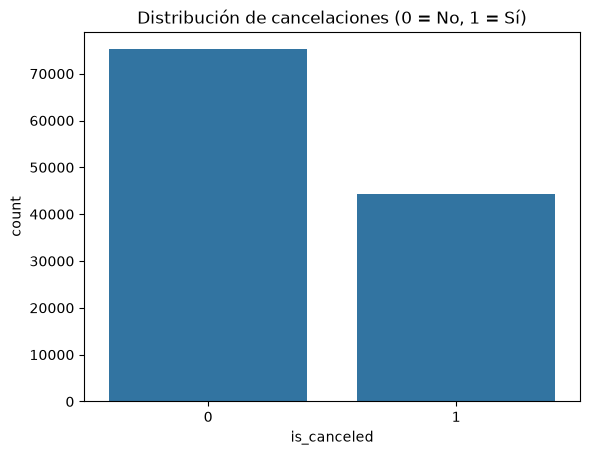

In [33]:
sns.countplot(data=df, x="is_canceled")
plt.title("Distribución de cancelaciones (0 = No, 1 = Sí)")
plt.show()

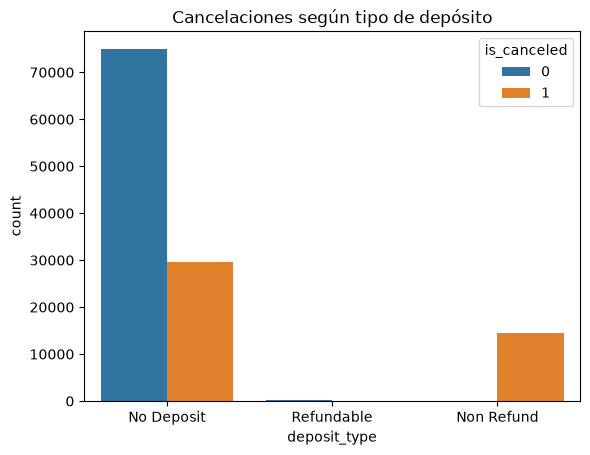

In [34]:
sns.countplot(data=df, x="deposit_type", hue="is_canceled")
plt.title("Cancelaciones según tipo de depósito")
plt.show()

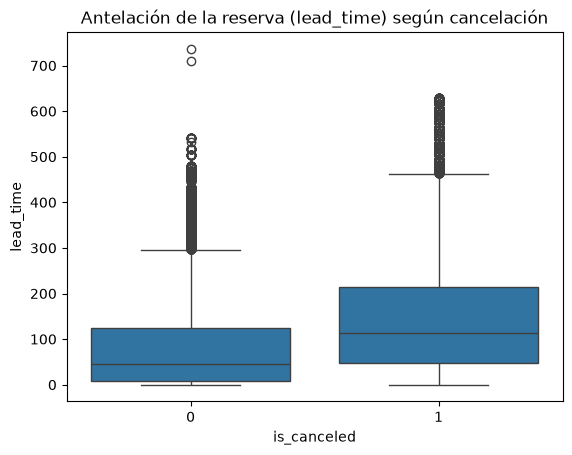

In [35]:
sns.boxplot(data=df, x="is_canceled", y="lead_time")
plt.title("Antelación de la reserva (lead_time) según cancelación")
plt.show()

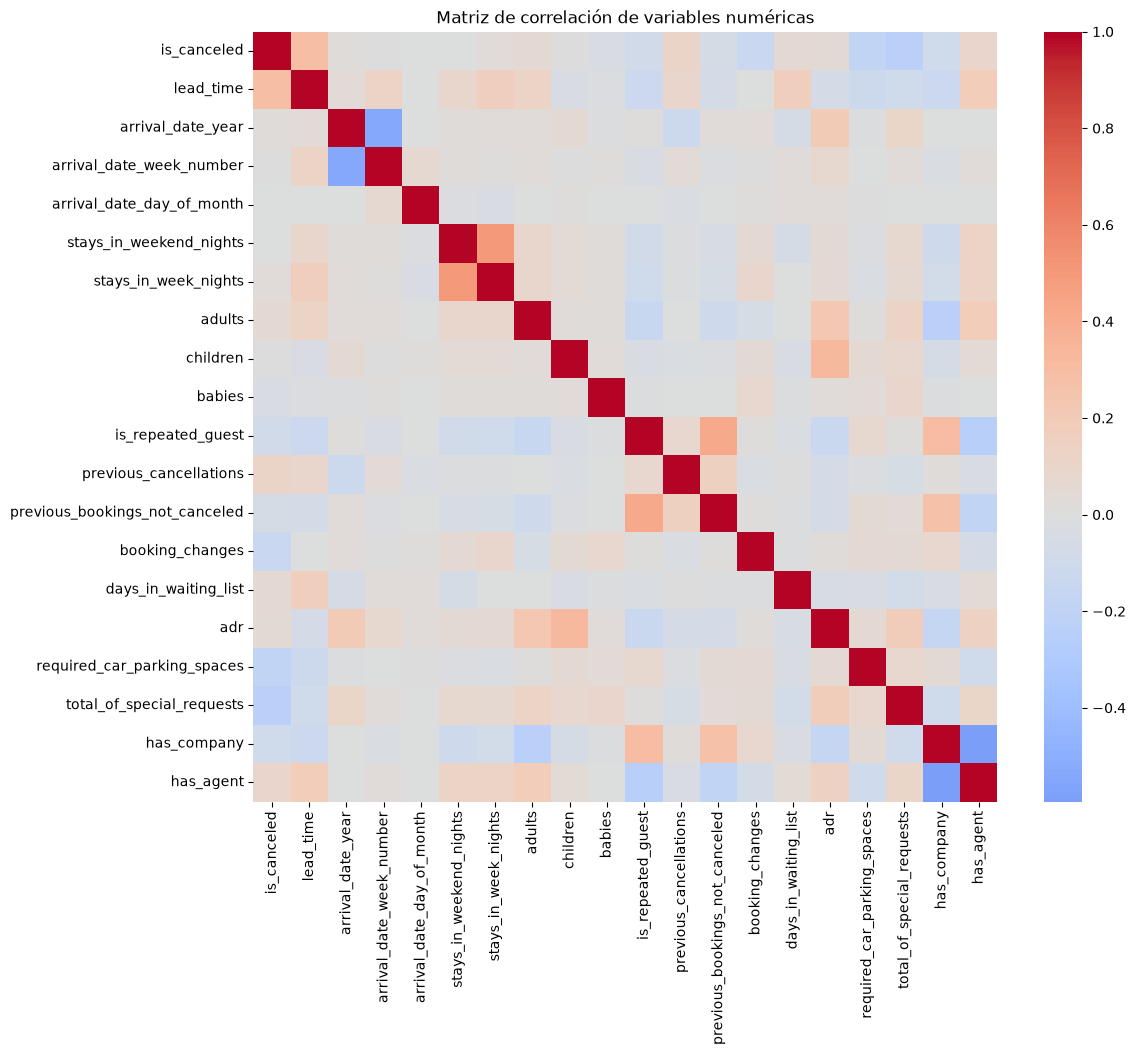

In [36]:
plt.figure(figsize=(12, 10))
correlaciones = df.select_dtypes(include="number").corr()
sns.heatmap(correlaciones, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.show()